In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [10]:
feature_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

target_col = "residuals"

yerr_all = df["ZTF_sigma_mu"]

X = df[feature_cols]
y = df[target_col]

In [11]:
Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=42
)

# Optional: convert training pieces to numpy for easier CV indexing
Xtr_np = Xtr.to_numpy()
ytr_np = ytr.to_numpy()
yerr_tr_np = yerr_tr.to_numpy()

In [12]:
def weighted_rmse(y_true, y_pred, yerr):
    w = 1.0 / (yerr ** 2)
    return np.sqrt(np.sum(w * (y_true - y_pred) ** 2) / np.sum(w))

In [13]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "n_jobs": -1,
        "random_state": 42,
    }

    if params["bootstrap"]:
        params["max_samples"] = trial.suggest_float("max_samples", 0.5, 1.0)

    rf = RandomForestRegressor(**params)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    for train_idx, val_idx in kf.split(Xtr_np):
        X_fold_tr = Xtr_np[train_idx]
        X_fold_val = Xtr_np[val_idx]

        y_fold_tr = ytr_np[train_idx]
        y_fold_val = ytr_np[val_idx]

        yerr_fold_tr = yerr_tr_np[train_idx]
        yerr_fold_val = yerr_tr_np[val_idx]

        w_fold_tr = 1.0 / (yerr_fold_tr ** 2)

        rf.fit(X_fold_tr, y_fold_tr, sample_weight=w_fold_tr)
        y_fold_pred = rf.predict(X_fold_val)

        score = weighted_rmse(y_fold_val, y_fold_pred, yerr_fold_val)
        fold_scores.append(score)

    return np.mean(fold_scores)

In [14]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:", study.best_trial.number)
print("Best weighted CV RMSE:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

[I 2026-04-07 14:23:41,012] A new study created in memory with name: no-name-ff8886a3-fe48-43b5-bc0e-95780045de6a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-07 14:23:42,458] Trial 0 finished with value: 0.16687418817388813 and parameters: {'n_estimators': 800, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True, 'max_samples': 0.6676976152254348}. Best is trial 0 with value: 0.16687418817388813.
[I 2026-04-07 14:23:43,450] Trial 1 finished with value: 0.1692126658370959 and parameters: {'n_estimators': 700, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.16687418817388813.
[I 2026-04-07 14:23:44,193] Trial 2 finished with value: 0.16583020852408947 and parameters: {'n_estimators': 400, 'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True, 'max_samples': 0.6094696958872976}. Best is trial 2 with value: 0.16583020852408947.
[I 2026-04-07 14:23:45,033] Trial 3 finished with value: 0.16981653788919146 and parameters: {'n_estimators': 60

In [15]:
best_params = study.best_params.copy()
best_params["n_jobs"] = -1
best_params["random_state"] = 42

rf = RandomForestRegressor(**best_params)

w = 1.0 / (yerr_tr.to_numpy() ** 2)

rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

In [16]:
test_weighted_rmse = weighted_rmse(yte.to_numpy(), yhat, yerr_te.to_numpy())
test_rmse = np.sqrt(mean_squared_error(yte, yhat))

print("Test weighted RMSE:", test_weighted_rmse)
print("Test RMSE:", test_rmse)

Test weighted RMSE: 0.18084358660716734
Test RMSE: 0.19501396534735457


In [17]:
print("Feature Importances:")
feature_importances = pd.Series(rf.feature_importances_, index=feature_cols)
print(feature_importances.sort_values(ascending=False))

Feature Importances:
DESI_FASTSPEC_g_minus_r    0.280643
DESI_FASTSPEC_DN4000       0.170514
DESI_FASTSPEC_LOGMSTAR     0.161118
DESI_METADATA_Z            0.156817
DESI_FASTSPEC_AGE          0.133818
DESI_FASTSPEC_VDISP        0.054481
DESI_FASTSPEC_SFR          0.042609
dtype: float64


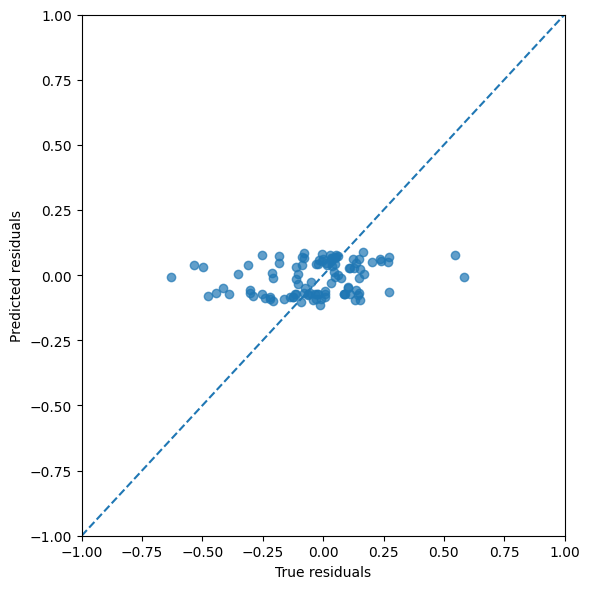

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(yte, yhat, alpha=0.7)
plt.xlabel("True residuals")
plt.ylabel("Predicted residuals")
plt.axline((0, 0), slope=1, linestyle="--")

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

# Helper Function That Plots The Scatter with Error Bars #


Note that there is now a new way to bin the data here:


### Binned residuals and bin-level error bars

For each host-galaxy variable $x$, we bin the data into $N_{\rm bin}$ intervals along the $x$-axis. In bin $k$, let the set of supernova Hubble residuals be $\{\Delta\mu_i\}_{i=1}^{N_k}$, where $N_k$ is the number of objects in that bin. We plot the binned point as the mean residual in the bin,

$
\overline{\Delta\mu}_k=\frac{1}{N_k}\sum_{i=1}^{N_k}\Delta\mu_i,
$

evaluated at the bin center

$
x_k = \frac{1}{2}\left(x_{k,\min}+x_{k,\max}\right).
$

To represent the *spread* of residuals within each bin (rather than the uncertainty on the mean), the error bar for bin $k$ is taken to be the sample standard deviation of the residuals in that bin,

$
\sigma_{k,\rm bin}=\sqrt{\frac{1}{N_k-1}\sum_{i=1}^{N_k}\left(\Delta\mu_i-\overline{\Delta\mu}_k\right)^2}.
$

This choice yields error bars that reflect the intrinsic dispersion (plus measurement scatter) of $\Delta\mu$ among supernovae within each $x$-bin, and therefore does not shrink artificially as $N_k$ becomes large (in contrast to the standard error on the mean, $\sigma_{\overline{\Delta\mu}} \propto 1/\sqrt{N_k}$).

In [ ]:
# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.

nbins = 10

def scatter_with_errors(ax, xcol, nbins=None, xerr_col=None, xerr_direct_col=None):

    # Raw values
    x = df[xcol]
    y = df["residuals"]
    yerr = df["ZTF_sigma_mu"]
    
    # Optional horizontal error bars
    if xerr_col is not None:
        xerr = 1.0 / np.sqrt(df[xerr_col])
    # accomodation function for when the xerr is already directly given
    # as part of the SALT2 Curve data release. 
    elif xerr_direct_col is not None: 
        xerr = df[xerr_direct_col]
    else:
        xerr = None #has to be parsed or will crash errorbar function.

    # --- sigma clipping in y (vertical axis) ---
    # NOTE: sigma clipping has been moved OUTSIDE this function.
    # This function now assumes `mask` already includes whatever global sigma-clip
    # (or other cleaning) you want. In other words: this function only plots.
    #
    # UPDATE: we no longer pass a mask into this function because we now DROP
    # any unwanted rows upstream (sigma-clip + physical cuts). Therefore the
    # dataframe `df` is already the final cleaned sample when this function is called.

    # --- scatter cloud ---
    ax.scatter(x, y, **point_kwargs)

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    ax.errorbar(
        x, y, yerr=yerr, xerr = xerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.5,
        alpha=0.25,
        zorder=2,
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange")

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.
    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # If a bin is empty, skip it (avoid divide-by-zero)
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]

        # inverse-variance weights
        w = 1.0 / (err_bin**2)

        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)

        # propagated error on the mean
        y_mean = np.mean(y_bin)
        err_spread = np.std(y_bin, ddof=1)   # spread of points in the bin
        
        binned_y.append(y_mean)
        binned_yerr.append(err_spread)

    # Convert to arrays and only plot finite bins
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color="blue",
        markersize=7,
        capsize=3,
        zorder=5  # Keeps the data looking on top
    )

# Read in Our Data Frame #

In [3]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    521 non-null    float64
 1   ztfname                           521 non-null    object 
 2   ZTF_redshift                      521 non-null    float64
 3   ZTF_redshift_err                  521 non-null    float64
 4   ZTF_source                        521 non-null    object 
 5   ZTF_t0                            521 non-null    float64
 6   ZTF_x0                            521 non-null    float64
 7   ZTF_x1                            521 non-null    float64
 8   ZTF_c                             521 non-null    float64
 9   ZTF_t0_err                        521 non-null    float64
 10  ZTF_x0_err                        521 non-null    float64
 11  ZTF_x1_err                        521 non-null    float64
 12  ZTF_c_er

# Define Our Random Forest Classifier #

In [7]:
# =====================================================
# MI DAI ML TRAINING BLOCK 
# =====================================================

# Constructing the Random Forest Regressor Model
# Nothing is being fit here, uts just being made.

# Key properties of this model:
# - 1000 trees. 
# - Trees are allowed to grow deep (no max depth)
# - A minimum number of samples per leaf (5) enforces
#   local averaging and limits overfitting
# - At each split, only a subset of features is considered
#   (sqrt of total), encouraging diverse tree structures
# - Bootstrap resampling ensures each tree sees a slightly
#   different realization of the data

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
 )

# Defining Features and Setting Up Our Train/Test Split

feature_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

target_col = "residuals"

# Target Errors
yerr_all = df["ZTF_sigma_mu"]


X = df[feature_cols]
y = df[target_col]


# -----------------------------------------------------
# Train / test split
# -----------------------------------------------------
# NOTE: we split X, y, *and* yerr together so that
# the measurement errors stay perfectly aligned with
# the training and testing samples.

Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=42
)

# -----------------------------------------------------
# Defining standard error as well as weights and fitting the model
# -----------------------------------------------------
# In real code each data point would have its own weight to contribute to the fit.
# NOTE: in this dataset we DO have per-point errors (sigma_mu_meas),
# so we use inverse-variance weighting here.
# NOTE: the random forest algorythm does not take into account the uncertainties of training data. 
# In our case, we are telling the RF classifier to trust percisely fit SNIa more than those 
# with larger propagated uncertainties. 

w = 1.0 / (yerr_tr**2)

rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

print("Feature Importances:")
feature_importances = pd.Series(rf.feature_importances_, index=feature_cols)
print(feature_importances.sort_values(ascending=False))

Feature Importances:
DESI_FASTSPEC_g_minus_r    0.227865
DESI_FASTSPEC_DN4000       0.180796
DESI_METADATA_Z            0.160108
DESI_FASTSPEC_AGE          0.136443
DESI_FASTSPEC_LOGMSTAR     0.136004
DESI_FASTSPEC_VDISP        0.082890
DESI_FASTSPEC_SFR          0.075894
dtype: float64
